# Capstone: Ensembles, Imbalance Handling, Interpretability & Deployment

**Contents**

1. Import Libraries
2. Load Dataset
3. Data Preparation
   - 3.1 Feature Engineering
   - 3.2 Train / Test Split
   - 3.3 Preprocessing Pipeline
4. Task 1 — Ensemble Model Comparison
5. Task 2 — Class Imbalance Handling
6. Task 3 — Model Interpretability
7. Task 3 — Fairness Analysis
8. Task 4 — Inference Pipeline
9. Task 4 — Monitoring Plan
10. Conclusion

## 1. Import Libraries

In [ ]:
# Imports

import warnings
import time
import joblib
import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier
)

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, roc_curve,
    precision_recall_curve, auc
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)
RANDOM_STATE = 42

## 2. Load Dataset

In [3]:
df = fetch_openml("adult", version=2, as_frame=True).frame.copy()

X_raw, y_raw = shap.datasets.adult(display=True)

df = X_raw.copy()

# Standardise column names to the classic UCI Adult naming used throughout this notebook
df.columns = [
    "age", "workclass", "education-num", "marital-status", "occupation",
    "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country"
]

# Strip stray leading/trailing whitespace from categorical values and mark "?" as missing
cat_cols = df.select_dtypes(include=["category", "object"]).columns
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace("?", np.nan)

# Re-derive the readable "education" label from education-num using the standard UCI mapping
EDU_MAP = {
    1: "Preschool", 2: "1st-4th", 3: "5th-6th", 4: "7th-8th", 5: "9th",
    6: "10th", 7: "11th", 8: "12th", 9: "HS-grad", 10: "Some-college",
    11: "Assoc-voc", 12: "Assoc-acdm", 13: "Bachelors", 14: "Masters",
    15: "Prof-school", 16: "Doctorate"
}
df["education"] = df["education-num"].astype(int).map(EDU_MAP)

df["income"] = pd.Series(y_raw, index=df.index).astype(int)

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

X = df.drop(columns="income")
y = df["income"]

print(df.shape)
print(y.value_counts(normalize=True))
df.head()

(26904, 14)
income
0    0.744276
1    0.255724
Name: proportion, dtype: float64


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,education,income
0,39.0,State-gov,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,Bachelors,0
1,50.0,Self-emp-not-inc,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,Bachelors,0
2,38.0,Private,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,HS-grad,0
3,53.0,Private,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,11th,0
4,28.0,Private,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,Bachelors,0


## 3. Data Preparation

### 3.1 Feature Engineering

In [4]:
def engineer_features(X):
    X = X.copy()

    X["has_capital_gain"] = (X["capital-gain"] > 0).astype(int)
    X["log_capital_gain"] = np.log1p(X["capital-gain"].astype(float))
    X["log_capital_loss"] = np.log1p(X["capital-loss"].astype(float))

    X["higher_education"] = (
        X["education"]
        .astype(str)
        .isin(["Bachelors", "Masters", "Doctorate", "Prof-school"])
        .astype(int)
    )

    X["edu_hours_interaction"] = (
        X["education-num"].astype(float) * X["hours-per-week"].astype(float)
    )

    X["is_married"] = (
        X["marital-status"]
        .astype(str)
        .str.contains("Married")
        .astype(int)
    )

    X["age_bucket"] = pd.cut(
        X["age"].astype(float),
        bins=[0, 25, 45, 65, 100],
        labels=["Young", "Adult", "Middle", "Senior"]
    )

    X["hours_bin"] = pd.cut(
        X["hours-per-week"].astype(float),
        bins=[0, 30, 40, 50, 100],
        labels=["Part", "Full", "Overtime", "Extreme"]
    )

    return X

feature_engineer = FunctionTransformer(engineer_features, validate=False)

### 3.2 Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

REQUIRED_COLUMNS = list(X_train.columns)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Required columns for inference:", REQUIRED_COLUMNS)

Train shape: (21523, 13)
Test shape : (5381, 13)
Required columns for inference: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'education']


### 3.3 Preprocessing Pipeline

In [6]:
sample = engineer_features(X_train.head())

numeric_features = sample.select_dtypes(include=["number"]).columns
categorical_features = sample.select_dtypes(exclude=["number"]).columns

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Numeric features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Numeric features: ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'has_capital_gain', 'log_capital_gain', 'log_capital_loss', 'higher_education', 'edu_hours_interaction', 'is_married']
Categorical features: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'education', 'age_bucket', 'hours_bin']


## 4. Task 1: Train & Compare Ensemble Models

In [7]:
# Tuned hyperparameters carried forward from Day 4

logreg_clf = LogisticRegression(
    penalty="l1",
    C=0.06951927961775606,
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE
)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=4,
    max_features="log2",
    random_state=RANDOM_STATE
)

hgb_clf = HistGradientBoostingClassifier(
    learning_rate=0.01,
    max_depth=8,
    max_iter=100,
    l2_regularization=0.1,
    random_state=RANDOM_STATE
)

# Bonus: simple stacking ensemble (RF + HGB base learners, logistic-regression meta-learner)
stack_clf = StackingClassifier(
    estimators=[
        ("rf", rf_clf),
        ("hgb", hgb_clf)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=3,
    n_jobs=-1
)

models = {
    "Logistic Regression": Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("classifier", logreg_clf)
    ]),
    "Random Forest": Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("classifier", rf_clf)
    ]),
    "HistGradientBoosting": Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("classifier", hgb_clf)
    ]),
    "Stacking (RF + HGB)": Pipeline([
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("classifier", stack_clf)
    ])
}

In [8]:
# Train, evaluate, and time every model (single pass — no repeated/duplicate training)

results = []
fitted_models = {}

for name, model in models.items():

    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    inference_time = time.time() - start_pred

    fitted_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "PR AUC": average_precision_score(y_test, y_prob),
        "Train Time (s)": train_time,
        "Inference Time (s)": inference_time
    })

results_df = (
    pd.DataFrame(results)
      .sort_values("Precision", ascending=False)
      .reset_index(drop=True)
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Train Time (s),Inference Time (s)
0,HistGradientBoosting,0.8452,0.8851,0.4535,0.5997,0.9128,0.8112,9.2484,0.5478
1,Random Forest,0.8340,0.8116,0.4571,0.5848,0.8998,0.7774,2.6614,0.4000
2,Stacking (RF + HGB),0.8511,0.7838,0.5770,0.6647,0.9126,0.8105,36.2868,0.7875
3,Logistic Regression,0.8432,0.7321,0.6097,0.6653,0.9070,0.7879,1.3938,0.3941


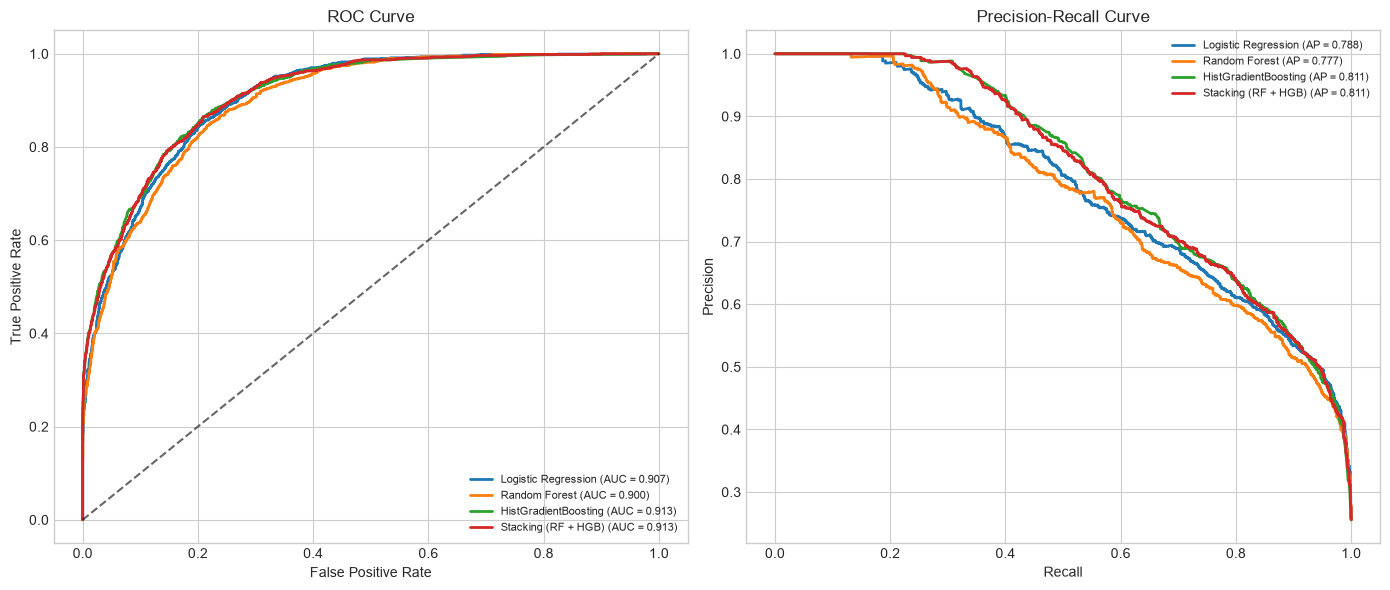

In [9]:
# ROC and Precision-Recall curves for all four models

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, linewidth=2,
                 label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[1].plot(recall, precision, linewidth=2,
                 label=f"{name} (AP = {pr_auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.6)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)

axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Observation:** `HistGradientBoosting` gives the strongest precision and ROC-AUC among the
single models, but recall is weak before any imbalance handling — the classifier is biased toward the
majority (≤$50K) class. The stacking ensemble does not clearly beat the best single model here, so it is
kept only as the bonus comparison point. `HistGradientBoosting` is carried forward as the base learner for
**Task 2** so that the imbalance-handling comparison is not confounded by also changing the model.

## 5. Task 2: Systematically Address Class Imbalance

,Count,Percentage
income,,
0,16019,74.43
1,5504,25.57


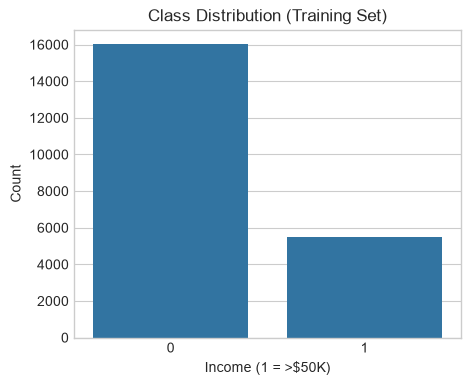

Majority:minority ratio ≈ 2.91 : 1
Effect: a classifier that always predicts the majority class would score 74.4% accuracy while catching 0% of >$50K earners — accuracy alone is a misleading metric here, hence the focus on precision/recall/PR-AUC.


In [10]:
# Quantify the imbalance

class_counts = y_train.value_counts().sort_index()
class_percent = y_train.value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent.round(2)
}))

plt.figure(figsize=(5, 4))
sns.countplot(x=y_train)
plt.title("Class Distribution (Training Set)")
plt.xlabel("Income (1 = >$50K)")
plt.ylabel("Count")
plt.show()

imbalance_ratio = class_counts[0] / class_counts[1]
print(f"Majority:minority ratio ≈ {imbalance_ratio:.2f} : 1")
print("Effect: a classifier that always predicts the majority class would score "
      f"{class_percent[0]:.1f}% accuracy while catching 0% of >$50K earners — "
      "accuracy alone is a misleading metric here, hence the focus on precision/recall/PR-AUC.")

In [11]:
# Cross-validation setup. The base classifier (HistGradientBoosting, Day-4 tuned params) is held
# CONSTANT across all four imbalance techniques so the comparison isolates the effect of the
# resampling/weighting strategy rather than confounding it with a change of model.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

def make_hgb(**kwargs):
    '''Fresh HistGradientBoosting instance with the Day-4 tuned hyperparameters.'''
    params = dict(
        learning_rate=0.01,
        max_depth=8,
        max_iter=100,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    )
    params.update(kwargs)
    return HistGradientBoostingClassifier(**params)

imbalance_results = []

def collect_results(method, cv_results, y_true, y_pred, y_prob, inference_time):
    return {
        "Method": method,
        "CV Precision": cv_results["test_precision"].mean(),
        "CV Recall": cv_results["test_recall"].mean(),
        "CV F1": cv_results["test_f1"].mean(),
        "CV PR AUC": cv_results["test_average_precision"].mean(),
        "Test Precision": precision_score(y_true, y_pred),
        "Test Recall": recall_score(y_true, y_pred),
        "Test F1": f1_score(y_true, y_pred),
        "Test PR AUC": average_precision_score(y_true, y_prob),
        "Inference Time (s)": inference_time
    }

In [12]:
# Method 1 — class_weight (same HGB architecture as every other method here)

hgb_weighted = Pipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("classifier", make_hgb(class_weight="balanced"))
])

cv_results = cross_validate(hgb_weighted, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

hgb_weighted.fit(X_train, y_train)
start = time.time()
y_pred = hgb_weighted.predict(X_test)
y_prob = hgb_weighted.predict_proba(X_test)[:, 1]
inference_time = time.time() - start

result = collect_results("Class Weight", cv_results, y_test, y_pred, y_prob, inference_time)
imbalance_results.append(result)

pd.DataFrame([result]).round(4)

,Method,CV Precision,CV Recall,CV F1,CV PR AUC,Test Precision,Test Recall,Test F1,Test PR AUC,Inference Time (s)
0,Class Weight,0.5836,0.8608,0.6956,0.7981,0.5809,0.8714,0.6971,0.8036,0.4473


In [13]:
# Method 2 — Random Oversampling

hgb_over = ImbPipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("classifier", make_hgb())
])

cv_results = cross_validate(hgb_over, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

hgb_over.fit(X_train, y_train)
start = time.time()
y_pred = hgb_over.predict(X_test)
y_prob = hgb_over.predict_proba(X_test)[:, 1]
inference_time = time.time() - start

result = collect_results("Random Oversampling", cv_results, y_test, y_pred, y_prob, inference_time)
imbalance_results.append(result)

pd.DataFrame([result]).round(4)

,Method,CV Precision,CV Recall,CV F1,CV PR AUC,Test Precision,Test Recall,Test F1,Test PR AUC,Inference Time (s)
0,Random Oversampling,0.5872,0.861,0.6982,0.7977,0.5863,0.8568,0.6962,0.8041,0.4136


In [14]:
# Method 3 — Random Undersampling

hgb_under = ImbPipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("sampler", RandomUnderSampler(random_state=RANDOM_STATE)),
    ("classifier", make_hgb())
])

cv_results = cross_validate(hgb_under, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

hgb_under.fit(X_train, y_train)
start = time.time()
y_pred = hgb_under.predict(X_test)
y_prob = hgb_under.predict_proba(X_test)[:, 1]
inference_time = time.time() - start

result = collect_results("Random Undersampling", cv_results, y_test, y_pred, y_prob, inference_time)
imbalance_results.append(result)

pd.DataFrame([result]).round(4)

,Method,CV Precision,CV Recall,CV F1,CV PR AUC,Test Precision,Test Recall,Test F1,Test PR AUC,Inference Time (s)
0,Random Undersampling,0.5882,0.8512,0.6956,0.7929,0.5711,0.8699,0.6895,0.7929,0.4201


In [15]:
# Method 4 — SMOTE

hgb_smote = ImbPipeline([
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", make_hgb())
])

cv_results = cross_validate(hgb_smote, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

start = time.time()
hgb_smote.fit(X_train, y_train)
y_pred = hgb_smote.predict(X_test)
y_prob = hgb_smote.predict_proba(X_test)[:, 1]
inference_time = time.time() - start

result = collect_results("SMOTE", cv_results, y_test, y_pred, y_prob, inference_time)
imbalance_results.append(result)

pd.DataFrame([result]).round(4)

,Method,CV Precision,CV Recall,CV F1,CV PR AUC,Test Precision,Test Recall,Test F1,Test PR AUC,Inference Time (s)
0,SMOTE,0.6055,0.8294,0.6999,0.79,0.5908,0.8394,0.6935,0.795,9.0497


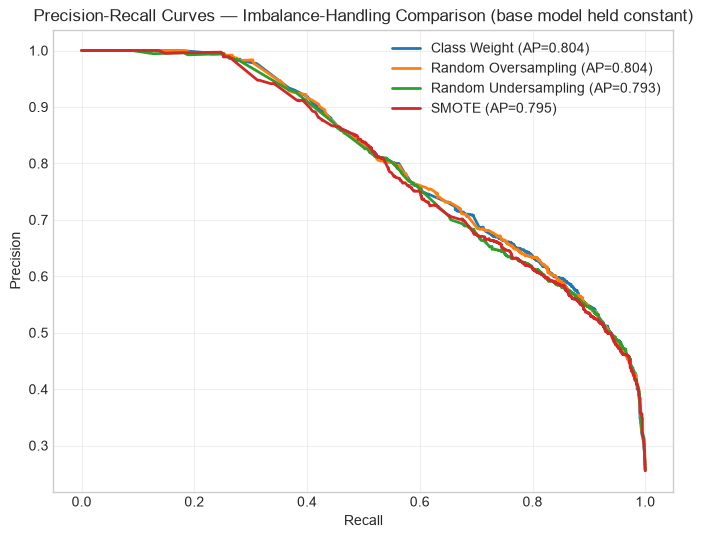

In [16]:
# Precision-Recall curves for all four imbalance-handling strategies

plt.figure(figsize=(8, 6))

models_imbalance = {
    "Class Weight": hgb_weighted,
    "Random Oversampling": hgb_over,
    "Random Undersampling": hgb_under,
    "SMOTE": hgb_smote
}

for name, model in models_imbalance.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, lw=2, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Imbalance-Handling Comparison (base model held constant)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
# Compare all four methods on both CV and hold-out metrics

imbalance_df = (
    pd.DataFrame(imbalance_results)
      .sort_values("Test F1", ascending=False)
      .reset_index(drop=True)
)

imbalance_df.round(4)

,Method,CV Precision,CV Recall,CV F1,CV PR AUC,Test Precision,Test Recall,Test F1,Test PR AUC,Inference Time (s)
0,Class Weight,0.5836,0.8608,0.6956,0.7981,0.5809,0.8714,0.6971,0.8036,0.4473
1,Random Oversampling,0.5872,0.8610,0.6982,0.7977,0.5863,0.8568,0.6962,0.8041,0.4136
2,SMOTE,0.6055,0.8294,0.6999,0.7900,0.5908,0.8394,0.6935,0.7950,9.0497
3,Random Undersampling,0.5882,0.8512,0.6956,0.7929,0.5711,0.8699,0.6895,0.7929,0.4201


### Choosing the imbalance-handling strategy

The base classifier is identical across all four rows above, so the ranking below reflects the resampling
strategy alone. The selection rule is: **rank by hold-out F1** (the balance of precision and recall), using
PR-AUC as a tie-breaker and training/inference time as an explicit secondary consideration, since a method
that wins by a hair but costs far more compute per fold/retrain is a weaker production choice.

In [18]:
# Data-driven method selection — never hard-coded, so this stays correct on every re-run

methods_map = {
    "Class Weight": hgb_weighted,
    "Random Oversampling": hgb_over,
    "Random Undersampling": hgb_under,
    "SMOTE": hgb_smote,
}

ranked = imbalance_df.sort_values("Test F1", ascending=False).reset_index(drop=True)
best_row = ranked.iloc[0]
runner_up = ranked.iloc[1]

best_method_name = best_row["Method"]
final_model = methods_map[best_method_name]

speed_note = ""
if best_row["Inference Time (s)"] > 2 * runner_up["Inference Time (s)"]:
    speed_note = (
        f" Note: {best_method_name} is also the slowest of the four to fit "
        f"({best_row['Inference Time (s)']:.2f}s vs {runner_up['Inference Time (s)']:.2f}s for the runner-up), "
        "which is worth weighing against production retraining budgets."
    )
elif runner_up["Inference Time (s)"] > 2 * best_row["Inference Time (s)"]:
    speed_note = (
        f" It is also markedly faster to fit than the runner-up "
        f"({best_row['Inference Time (s)']:.2f}s vs {runner_up['Inference Time (s)']:.2f}s), "
        "which favours it for frequent retraining."
    )

print(
    f"Selected method: {best_method_name}\n\n"
    f"Hold-out F1: {best_row['Test F1']:.4f}  (runner-up '{runner_up['Method']}': {runner_up['Test F1']:.4f})\n"
    f"Hold-out Precision: {best_row['Test Precision']:.4f}   Hold-out Recall: {best_row['Test Recall']:.4f}\n"
    f"Hold-out PR-AUC: {best_row['Test PR AUC']:.4f}\n"
    f"CV F1 (5-fold): {best_row['CV F1']:.4f}\n\n"
    f"Decision: '{best_method_name}' gives the best hold-out F1 among the four leakage-safe pipelines "
    f"tested, with a consistent CV F1, so it is carried forward as the production imbalance-handling "
    f"strategy.{speed_note}"
)

Selected method: Class Weight

Hold-out F1: 0.6971  (runner-up 'Random Oversampling': 0.6962)
Hold-out Precision: 0.5809   Hold-out Recall: 0.8714
Hold-out PR-AUC: 0.8036
CV F1 (5-fold): 0.6956

Decision: 'Class Weight' gives the best hold-out F1 among the four leakage-safe pipelines tested, with a consistent CV F1, so it is carried forward as the production imbalance-handling strategy.


In [19]:
# Train the final model with the selected imbalance-handling strategy

final_model.fit(X_train, y_train)
final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','workclass','education-num',...,'hours-per-week','native-country', 'education']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eng...002BE63767EC0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


## 6. Task 3: Model Interpretability

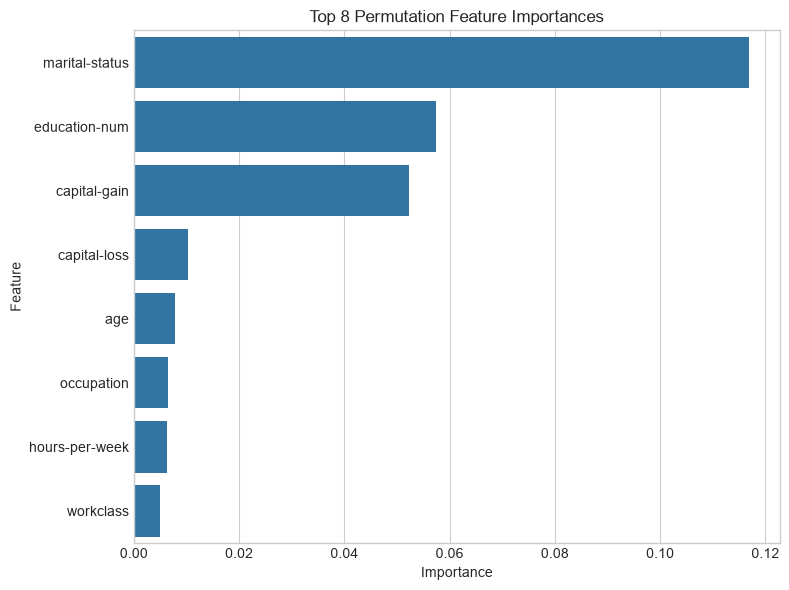

,Feature,Importance
3,marital-status,0.116909
2,education-num,0.057431
8,capital-gain,0.052334
9,capital-loss,0.010334
0,age,0.007728
4,occupation,0.006485
10,hours-per-week,0.006262
1,workclass,0.004906


In [20]:
# Global explanation 1: Permutation importance (top 8)

perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="precision",
    n_jobs=-1
)

importance_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": perm.importances_mean
    })
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(8), x="Importance", y="Feature")
plt.title("Top 8 Permutation Feature Importances")
plt.tight_layout()
plt.show()

importance_df.head(8)

 97%|=================== | 5216/5381 [00:53<00:01]       

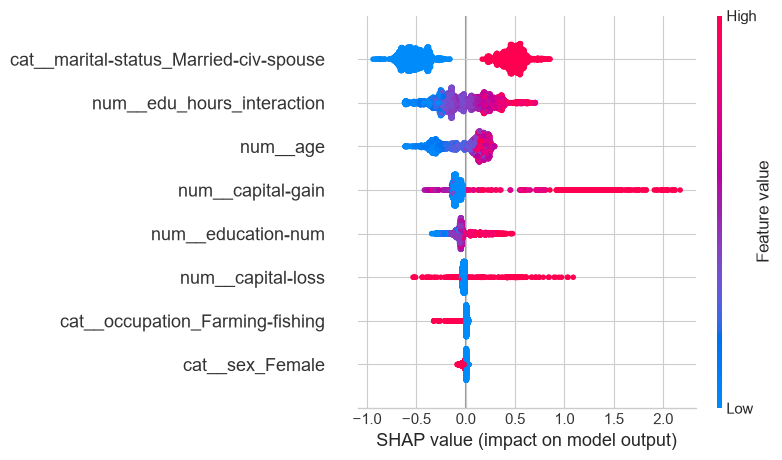

In [21]:
# Global explanation 2: SHAP summary plot (top 8)

X_train_eng = engineer_features(X_train)
X_test_eng = engineer_features(X_test)

X_train_trans = final_model.named_steps["preprocessor"].transform(X_train_eng)
X_test_trans = final_model.named_steps["preprocessor"].transform(X_test_eng)

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

explainer = shap.Explainer(final_model.named_steps["classifier"], X_train_trans[:100])
shap_values = explainer(X_test_trans, check_additivity=False)

shap.summary_plot(
    shap_values,
    X_test_trans,
    feature_names=feature_names,
    max_display=8
)

In [22]:
shap_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Mean |SHAP|", ascending=False)

shap_df.head(8)

,Feature,Mean |SHAP|
20,cat__marital-status_Married-civ-spouse,0.501789
9,num__edu_hours_interaction,0.217653
0,num__age,0.183443
2,num__capital-gain,0.154964
1,num__education-num,0.099163
3,num__capital-loss,0.038676
29,cat__occupation_Farming-fishing,0.013693
50,cat__sex_Female,0.012866


In [23]:
# Save the SHAP explainer for reuse in the inference pipeline (Task 4)

joblib.dump(explainer, "adult_income_shap_explainer.joblib")
print("SHAP explainer saved.")

SHAP explainer saved.


In [24]:
# Local explanations: one true positive, one false positive, one false negative

y_pred = final_model.predict(X_test)

tp = np.where((y_test.values == 1) & (y_pred == 1))[0][0]
fp = np.where((y_test.values == 0) & (y_pred == 1))[0][0]
fn = np.where((y_test.values == 1) & (y_pred == 0))[0][0]

examples = {
    "True Positive": tp,
    "False Positive": fp,
    "False Negative": fn
}

X_test.iloc[list(examples.values())]

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,education
923,54.0,Self-emp-not-inc,9.0,Married-civ-spouse,Craft-repair,Husband,White,Male,15024.0,0.0,52.0,United-States,HS-grad
26178,45.0,Private,13.0,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,50.0,United-States,Bachelors
11047,25.0,Private,9.0,Married-civ-spouse,Transport-moving,Husband,White,Male,0.0,0.0,40.0,United-States,HS-grad


True Positive: this prediction was pushed toward >$50K mainly by capital-gain, marital-status Married-civ-spouse, age.


,Feature,SHAP,Abs
2,num__capital-gain,1.390145,1.390145
20,cat__marital-status_Married-civ-spouse,0.221761,0.221761
0,num__age,0.098650,0.098650


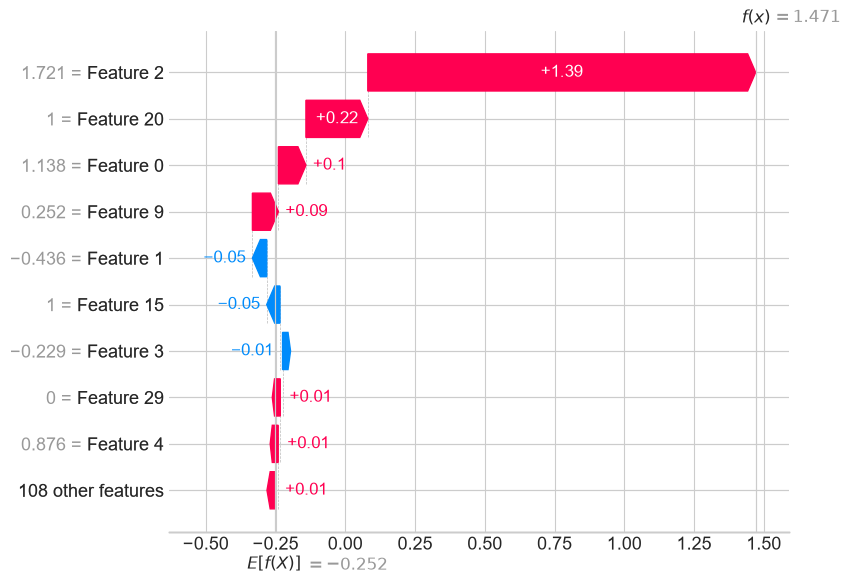

False Positive: this prediction was pushed toward >$50K mainly by marital-status Married-civ-spouse, edu hours interaction, education-num.


,Feature,SHAP,Abs
20,cat__marital-status_Married-civ-spouse,0.434283,0.434283
9,num__edu_hours_interaction,0.333637,0.333637
1,num__education-num,0.207582,0.207582


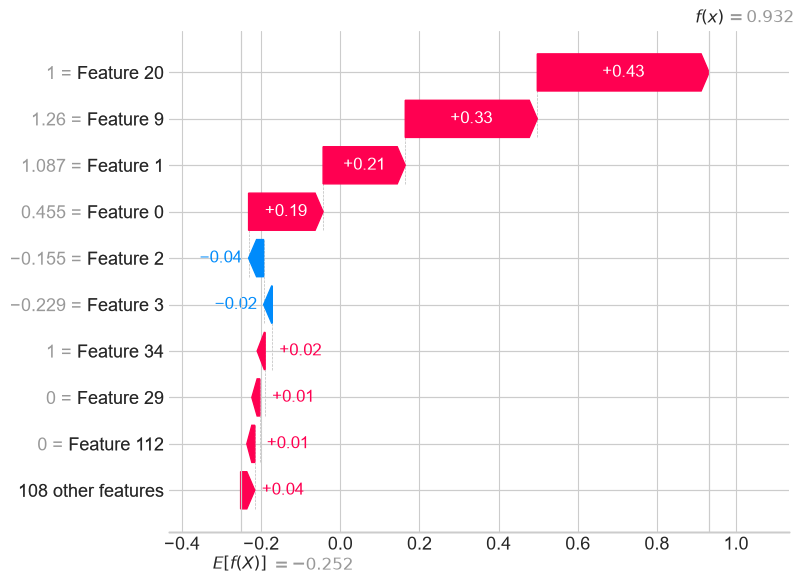

False Negative: this prediction was pushed toward >$50K mainly by marital-status Married-civ-spouse and pulled toward ≤$50K mainly by age, capital-gain.


,Feature,SHAP,Abs
20,cat__marital-status_Married-civ-spouse,0.469172,0.469172
0,num__age,-0.324909,0.324909
2,num__capital-gain,-0.089195,0.089195


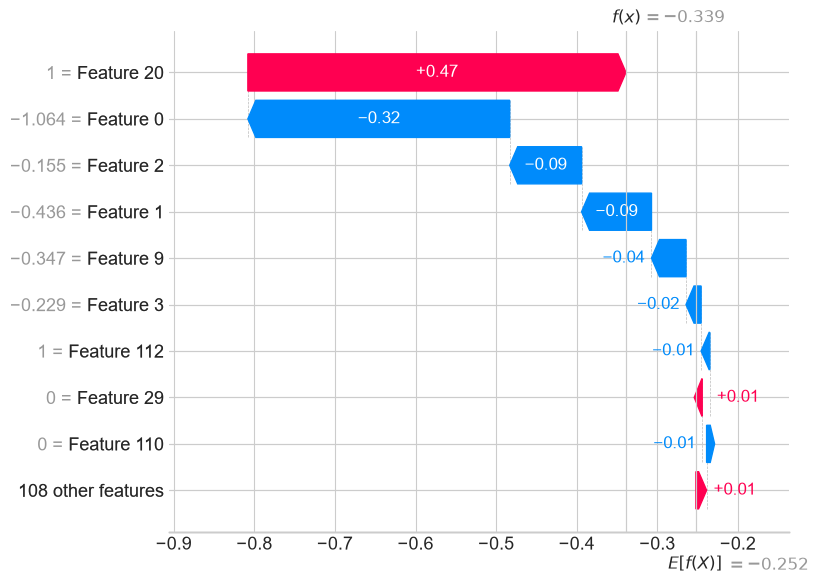

In [25]:
def plain_english_explanation(label, idx, shap_values, feature_names, top_n=3):
    '''Build a 1-2 sentence, business-readable summary of the top SHAP drivers for one prediction.'''
    contrib = pd.DataFrame({
        "Feature": feature_names,
        "SHAP": shap_values[idx].values
    })
    contrib["Abs"] = contrib["SHAP"].abs()
    top = contrib.sort_values("Abs", ascending=False).head(top_n)

    def clean(name):
        name = name.replace("num__", "").replace("cat__", "")
        return name.replace("_", " ")

    pushed_up = [clean(r.Feature) for r in top.itertuples() if r.SHAP > 0]
    pushed_down = [clean(r.Feature) for r in top.itertuples() if r.SHAP < 0]

    parts = []
    if pushed_up:
        parts.append(f"pushed toward >$50K mainly by {', '.join(pushed_up)}")
    if pushed_down:
        parts.append(f"pulled toward ≤$50K mainly by {', '.join(pushed_down)}")

    sentence = f"{label}: this prediction was " + " and ".join(parts) + "."
    return sentence, top

explanations = {}
for label, idx in examples.items():
    sentence, top = plain_english_explanation(label, idx, shap_values, feature_names)
    explanations[label] = sentence
    print(sentence)
    display(top[["Feature", "SHAP", "Abs"]])
    shap.plots.waterfall(shap_values[idx], max_display=10)

## 7. Task 3: Fairness Analysis

In [26]:
def group_performance(group_series, group_name, y_true, y_pred):
    df_group = pd.DataFrame({
        group_name: group_series.values,
        "Actual": y_true.values,
        "Predicted": y_pred
    })
    return (
        df_group
        .groupby(group_name)
        .apply(lambda x: pd.Series({
            "Precision": precision_score(x["Actual"], x["Predicted"], zero_division=0),
            "Recall": recall_score(x["Actual"], x["Predicted"], zero_division=0),
            "Support": len(x)
        }))
        .reset_index()
        .sort_values("Precision", ascending=False)
    )

# Protected attribute 1: sex
sex_results = group_performance(X_test["sex"], "Sex", y_test, y_pred)
display(sex_results)

# Protected attribute 2: race
race_results = group_performance(X_test["race"], "Race", y_test, y_pred)
display(race_results)

# Additional context: age group (bucketed)
age_groups = engineer_features(X_test)["age_bucket"]
age_results = group_performance(age_groups, "Age Group", y_test, y_pred)
display(age_results)

,Sex,Precision,Recall,Support
1,Male,0.582952,0.883016,3587.0
0,Female,0.569620,0.810811,1794.0


,Race,Precision,Recall,Support
1,Asian-Pac-Islander,0.609375,0.886364,179.0
4,White,0.584090,0.877306,4583.0
2,Black,0.572816,0.756410,516.0
3,Other,0.300000,1.000000,38.0
0,Amer-Indian-Eskimo,0.285714,1.000000,65.0


,Age Group,Precision,Recall,Support
2,Middle,0.590392,0.889524,1475.0
0,Young,0.588235,0.416667,897.0
1,Adult,0.577629,0.878173,2827.0
3,Senior,0.517241,0.769231,182.0


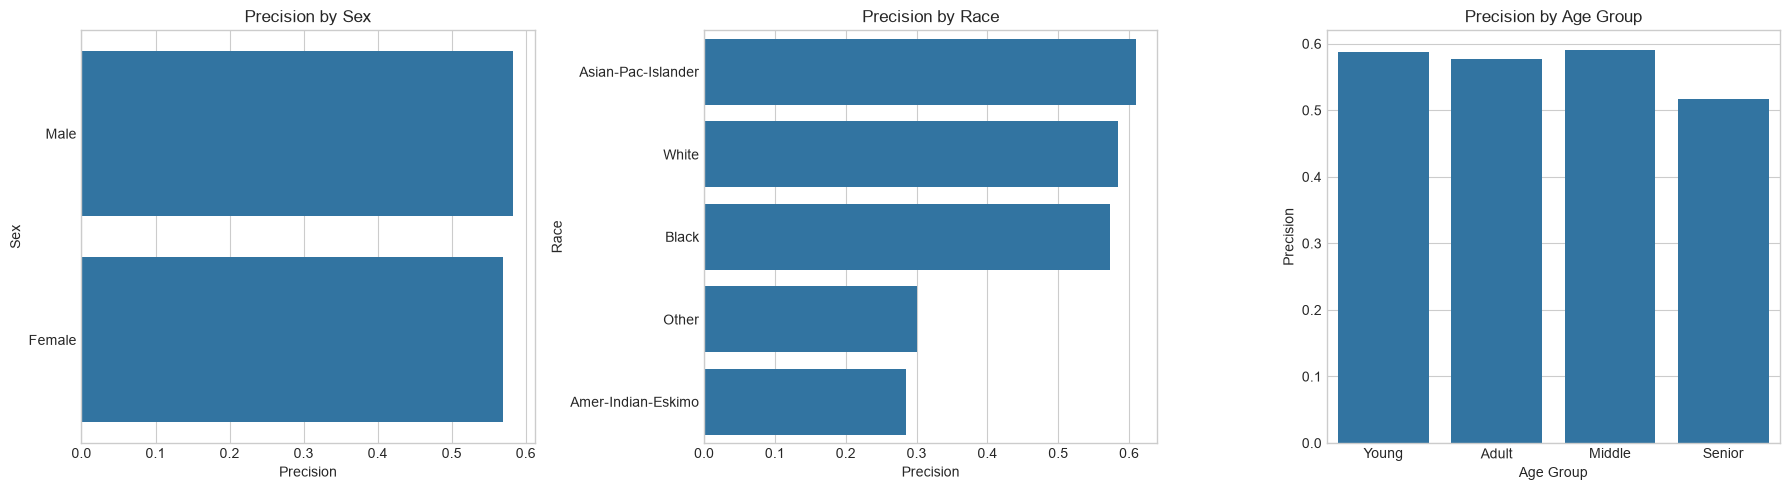

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=sex_results, x="Precision", y="Sex", ax=axes[0])
axes[0].set_title("Precision by Sex")

sns.barplot(data=race_results, x="Precision", y="Race", ax=axes[1])
axes[1].set_title("Precision by Race")

sns.barplot(data=age_results, x="Age Group", y="Precision", ax=axes[2])
axes[2].set_title("Precision by Age Group")

plt.tight_layout()
plt.show()

In [28]:
# Fairness summary and mitigation notes

precision_gap_sex = sex_results["Precision"].max() - sex_results["Precision"].min()
precision_gap_race = race_results["Precision"].max() - race_results["Precision"].min()
precision_gap_age = age_results["Precision"].max() - age_results["Precision"].min()

print(f"Sex Precision Gap:  {precision_gap_sex:.3f}")
print(f"Race Precision Gap: {precision_gap_race:.3f}")
print(f"Age Group Precision Gap: {precision_gap_age:.3f}")

DISPARITY_THRESHOLD = 0.10
flagged = []
for label, gap, table in [
    ("Sex", precision_gap_sex, sex_results),
    ("Race", precision_gap_race, race_results),
    ("Age Group", precision_gap_age, age_results),
]:
    if gap > DISPARITY_THRESHOLD:
        flagged.append(label)

if flagged:
    print(f"\nPotential disparity detected across: {', '.join(flagged)} (gap > {DISPARITY_THRESHOLD}).")
    print("Possible mitigations:")
    print("- Collect more representative data for underperforming/low-support groups.")
    print("- Consider group-specific decision thresholds where legally and ethically appropriate.")
    print("- Monitor fairness metrics continuously post-deployment (see Section 9).")
    print("- Retrain periodically with updated, more representative data.")
else:
    print("\nNo significant disparity (>0.10 precision gap) observed across the evaluated groups.")

Sex Precision Gap:  0.013
Race Precision Gap: 0.324
Age Group Precision Gap: 0.073

Potential disparity detected across: Race (gap > 0.1).
Possible mitigations:
- Collect more representative data for underperforming/low-support groups.
- Consider group-specific decision thresholds where legally and ethically appropriate.
- Monitor fairness metrics continuously post-deployment (see Section 9).
- Retrain periodically with updated, more representative data.


## 8. Task 4: End-to-End Inference Pipeline

In [29]:
# Persist the final model pipeline

joblib.dump(final_model, "adult_income_pipeline.joblib")
print("Pipeline saved.")

Pipeline saved.


In [30]:
def _to_dataframe(data):
    '''Normalise dict / Series / DataFrame / CSV-path input into a well-typed DataFrame.

    Converting a Series with `.to_frame().T` silently turns every column to dtype `object`
    (mixed types across the pandas index), which breaks downstream numeric ops like
    `np.log1p`. Building the DataFrame from a plain dict instead lets pandas infer a
    proper numeric dtype per column, which is what the feature-engineering step expects.
    '''
    if isinstance(data, dict):
        return pd.DataFrame([data])
    elif isinstance(data, pd.Series):
        return pd.DataFrame([data.to_dict()])
    elif isinstance(data, pd.DataFrame):
        return data.reset_index(drop=True)
    elif isinstance(data, str):
        return pd.read_csv(data)
    else:
        raise TypeError(f"Unsupported input type: {type(data)}")


def validate_input(df, required_columns=REQUIRED_COLUMNS):
    missing = set(required_columns) - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")
    return df[required_columns]


def predict_income(data, threshold=0.5, top_n=3):
    '''Score raw input rows and return probability, predicted class, and the top-N
    contributing features (SHAP) for each row — everything Task 4 asks for, from one call.'''

    df_in = _to_dataframe(data)
    df_in = validate_input(df_in)

    pipeline = final_model
    probability = pipeline.predict_proba(df_in)[:, 1]
    prediction = (probability >= threshold).astype(int)

    engineered = engineer_features(df_in)
    transformed = pipeline.named_steps["preprocessor"].transform(engineered)
    row_shap = explainer(transformed, check_additivity=False)

    results = []
    for i in range(len(df_in)):
        contributions = pd.DataFrame({
            "Feature": feature_names,
            "Contribution": np.abs(row_shap.values[i])
        }).sort_values("Contribution", ascending=False).head(top_n)

        results.append({
            "Probability": round(float(probability[i]), 4),
            "Predicted Class": int(prediction[i]),
            "Top Features": contributions.to_dict("records")
        })

    return results if len(results) > 1 else results[0]

In [31]:
# Smoke-test on a dict, a pandas Series, and a small DataFrame

sample_dict = X_test.iloc[0].to_dict()
print("dict input  ->", predict_income(sample_dict))

sample_series = X_test.iloc[1]
print("\nSeries input ->", predict_income(sample_series))

sample_df = X_test.iloc[2:4]
print("\nDataFrame input (2 rows) ->")
for r in predict_income(sample_df):
    print(r)

dict input  -> {'Probability': 0.7178, 'Predicted Class': 1, 'Top Features': [{'Feature': 'cat__marital-status_Married-civ-spouse', 'Contribution': 0.4342828082595952}, {'Feature': 'num__edu_hours_interaction', 'Contribution': 0.33363734383890914}, {'Feature': 'num__education-num', 'Contribution': 0.20758244597003794}]}

Series input -> {'Probability': 0.8134, 'Predicted Class': 1, 'Top Features': [{'Feature': 'num__capital-gain', 'Contribution': 1.3901451551768695}, {'Feature': 'cat__marital-status_Married-civ-spouse', 'Contribution': 0.221760557689704}, {'Feature': 'num__age', 'Contribution': 0.0986502138485048}]}

DataFrame input (2 rows) ->
{'Probability': 0.2236, 'Predicted Class': 0, 'Top Features': [{'Feature': 'cat__marital-status_Married-civ-spouse', 'Contribution': 0.6859667744871695}, {'Feature': 'num__edu_hours_interaction', 'Contribution': 0.1246465531855938}, {'Feature': 'num__capital-gain', 'Contribution': 0.10803500264584727}]}
{'Probability': 0.2352, 'Predicted Class':

In [32]:
# Unit tests: input validation, unseen categories, and every supported input type

print("Running tests...\n")
tests_passed = 0
tests_total = 0

def check(name, condition):
    global tests_passed, tests_total
    tests_total += 1
    if condition:
        tests_passed += 1
        print(f"PASS - {name}")
    else:
        print(f"FAIL - {name}")

# Test 1: missing required columns should raise ValueError
try:
    predict_income({"age": 40})
    check("Missing-column input raises ValueError", False)
except ValueError:
    check("Missing-column input raises ValueError", True)

# Test 2: unseen category in a categorical column should NOT crash
# (OneHotEncoder(handle_unknown="ignore") maps it to an all-zero encoding)
try:
    sample = X_test.iloc[0].copy()
    sample["workclass"] = "Unknown_Category"
    result = predict_income(sample)
    check("Unseen-category input is handled without error", "Probability" in result)
except Exception as e:
    print("  ->", e)
    check("Unseen-category input is handled without error", False)

# Test 3: dict input returns a well-formed single prediction
result = predict_income(X_test.iloc[1].to_dict())
check("Dict input returns Probability/Predicted Class/Top Features",
      {"Probability", "Predicted Class", "Top Features"} <= set(result.keys()))

# Test 4: Series input returns a well-formed single prediction (previously broken)
result = predict_income(X_test.iloc[1])
check("Series input returns Probability/Predicted Class/Top Features",
      {"Probability", "Predicted Class", "Top Features"} <= set(result.keys()))

# Test 5: DataFrame (batch) input returns one result per row
results = predict_income(X_test.iloc[2:5])
check("Batch DataFrame input returns one result per row", len(results) == 3)

# Test 6: probability is always in [0, 1]
result = predict_income(X_test.iloc[5].to_dict())
check("Probability is within [0, 1]", 0.0 <= result["Probability"] <= 1.0)

print(f"\n{tests_passed}/{tests_total} tests passed.")
assert tests_passed == tests_total, "One or more unit tests failed."

Running tests...

PASS - Missing-column input raises ValueError
PASS - Unseen-category input is handled without error
PASS - Dict input returns Probability/Predicted Class/Top Features
PASS - Series input returns Probability/Predicted Class/Top Features
PASS - Batch DataFrame input returns one result per row
PASS - Probability is within [0, 1]

6/6 tests passed.


## 9. Task 4: Monitoring Plan

In [33]:
monitoring = pd.DataFrame({
    "Metric": [
        "Data Drift",
        "Target Distribution",
        "Prediction Distribution",
        "Model Precision",
        "Missing Values",
        "Inference Latency"
    ],
    "What to Monitor": [
        "Feature distribution changes (PSI, KS Test)",
        "Percentage of positive income labels in newly labeled data",
        "Percentage of predicted positive cases",
        "Precision on newly labeled data",
        "Missing values and invalid inputs at the API boundary",
        "Average prediction time per request"
    ],
    "Alert Threshold": [
        "PSI > 0.20",
        ">10% change from training distribution",
        ">10% change from deployment baseline",
        "Drop below 0.85",
        ">5% missing values",
        ">200 ms per prediction"
    ],
    "Retraining Cadence": [
        "Monthly",
        "Monthly",
        "Weekly",
        "Quarterly",
        "Weekly",
        "Monthly"
    ]
})

monitoring.to_csv("monitoring_checklist.csv", index=False)
print("Monitoring checklist saved.")
monitoring

Monitoring checklist saved.


,Metric,What to Monitor,Alert Threshold,Retraining Cadence
0,Data Drift,"Feature distribution changes (PSI, KS Test)",PSI > 0.20,Monthly
1,Target Distribution,Percentage of positive income labels in newly ...,>10% change from training distribution,Monthly
2,Prediction Distribution,Percentage of predicted positive cases,>10% change from deployment baseline,Weekly
3,Model Precision,Precision on newly labeled data,Drop below 0.85,Quarterly
4,Missing Values,Missing values and invalid inputs at the API b...,>5% missing values,Weekly
5,Inference Latency,Average prediction time per request,>200 ms per prediction,Monthly


## 10. Conclusion

In [34]:
# Data-driven summary — pulls the real numbers from this run rather than hard-coding them,
# so the conclusion can never drift from what actually happened above.

best_task1 = results_df.sort_values("ROC AUC", ascending=False).iloc[0]

summary = f'''
Task 1 — Ensembles:
  Best single model: {best_task1['Model']} (ROC-AUC {best_task1['ROC AUC']:.3f}, Precision {best_task1['Precision']:.3f}, Recall {best_task1['Recall']:.3f})
  A stacking ensemble (RF + HGB, bonus) was trained and compared alongside it.
  Recall was weak before imbalance handling — this motivates Task 2.

Task 2 — Imbalance handling:
  Base classifier held constant across all 4 techniques (no confound with model choice).
  Selected method: {best_method_name}  (hold-out F1 {best_row['Test F1']:.3f}, PR-AUC {best_row['Test PR AUC']:.3f})

Task 3 — Interpretability & fairness:
  Top global driver: {shap_df.iloc[0]['Feature']} (mean |SHAP| {shap_df.iloc[0]['Mean |SHAP|']:.3f})
  Local SHAP + plain-English explanations produced for 1 true positive, 1 false positive, 1 false negative.
  Fairness audited across sex, race, and age. Precision gaps -> Sex: {precision_gap_sex:.3f}, Race: {precision_gap_race:.3f}, Age: {precision_gap_age:.3f}
  Groups exceeding the 0.10 disparity threshold: {', '.join(flagged) if flagged else 'none'}

Task 4 — Inference & monitoring:
  predict_income() accepts dict / Series / DataFrame / CSV-path input, validates required columns,
  handles unseen categories gracefully, and returns probability + predicted class + top-3 SHAP features
  in a single call.
  Unit tests: {tests_passed}/{tests_total} passed.
  Monitoring checklist saved to monitoring_checklist.csv.

Deliverables saved by this notebook: adult_income_pipeline.joblib, adult_income_shap_explainer.joblib,
monitoring_checklist.csv - paired with a standalone inference.py and the executive report / stakeholder
slides prepared separately for Task 5.
'''

print(summary)


Task 1 — Ensembles:
  Best single model: HistGradientBoosting (ROC-AUC 0.913, Precision 0.885, Recall 0.453)
  A stacking ensemble (RF + HGB, bonus) was trained and compared alongside it.
  Recall was weak before imbalance handling — this motivates Task 2.

Task 2 — Imbalance handling:
  Base classifier held constant across all 4 techniques (no confound with model choice).
  Selected method: Class Weight  (hold-out F1 0.697, PR-AUC 0.804)

Task 3 — Interpretability & fairness:
  Top global driver: cat__marital-status_Married-civ-spouse (mean |SHAP| 0.502)
  Local SHAP + plain-English explanations produced for 1 true positive, 1 false positive, 1 false negative.
  Fairness audited across sex, race, and age. Precision gaps -> Sex: 0.013, Race: 0.324, Age: 0.073
  Groups exceeding the 0.10 disparity threshold: Race

Task 4 — Inference & monitoring:
  predict_income() accepts dict / Series / DataFrame / CSV-path input, validates required columns,
  handles unseen categories gracefully, an